**Лачина Екатерина Андреевна, ИУ5-63Б**

**Рубежный контроль 2. Вариант 10.**

Тема: Методы построения моделей машинного обучения.

Методы: Дерево решений, Случайный лес.

Датасет: `gameandgrade new.csv` — данные об игровых привычках студентов и их академической успеваемости. Задача — **регрессия**: предсказать оценку студента (`Grade`) по набору признаков.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [2]:
df = pd.read_csv('gameandgrade new.csv')
df.head()

,Sex,School Code,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education,Grade,percentage
0,0,1,1,2,1,1,4,4,5,77.50,"7750,00%"
1,1,1,1,3,1,1,1,3,3,83.00,"8300,00%"
2,0,1,0,0,0,0,1,3,3,80.00,"8000,00%"
3,0,1,3,5,1,1,2,2,3,45.00,"4500,00%"
4,1,1,1,1,2,1,1,3,4,85.00,"8500,00%"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Sex               770 non-null    int64
 1   School Code       770 non-null    int64
 2   Playing Years     770 non-null    int64
 3   Playing Often     770 non-null    int64
 4   Playing Hours     770 non-null    int64
 5   Playing Games     770 non-null    int64
 6   Parent Revenue    770 non-null    int64
 7   Father Education  770 non-null    int64
 8   Mother Education  770 non-null    int64
 9   Grade             770 non-null    str  
 10  percentage        770 non-null    str  
dtypes: int64(9), str(2)
memory usage: 66.3 KB


### Предобработка данных

In [4]:
df['Grade'] = pd.to_numeric(df['Grade'], errors='coerce')
df = df.drop(columns=['percentage'])

print("Пропуски после парсинга Grade:")
print(df.isnull().sum())

Пропуски после парсинга Grade:
Sex                 0
School Code         0
Playing Years       0
Playing Often       0
Playing Hours       0
Playing Games       0
Parent Revenue      0
Father Education    0
Mother Education    0
Grade               1
dtype: int64


Столбец `percentage` содержит ту же информацию, что и `Grade`, в другом формате — удаляем его во избежание утечки данных. После парсинга `Grade` в числовой тип образовался один пропуск — удаляем соответствующую строку.

In [5]:
df = df.dropna(subset=['Grade']).reset_index(drop=True)

df = pd.get_dummies(df, columns=['School Code'], drop_first=False)

print(f"Размер датасета после предобработки: {df.shape}")
df.head(3)

Размер датасета после предобработки: (769, 20)


,Sex,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education,Grade,School Code_1,School Code_2,School Code_3,School Code_4,School Code_5,School Code_6,School Code_7,School Code_8,School Code_9,School Code_10,School Code_11
0,0,1,2,1,1,4,4,5,77.5,True,False,False,False,False,False,False,False,False,False,False
1,1,1,3,1,1,1,3,3,83.0,True,False,False,False,False,False,False,False,False,False,False
2,0,0,0,0,0,1,3,3,80.0,True,False,False,False,False,False,False,False,False,False,False


Признак `School Code` принимает 11 номинальных значений (коды школ) без естественного порядка, поэтому применяем One-Hot Encoding. Остальные признаки (`Sex`, `Playing Years`, `Playing Often`, `Playing Hours`, `Playing Games`, `Parent Revenue`, `Father Education`, `Mother Education`) уже представлены числами.

Пропусков в данных нет (кроме единственного, появившегося при парсинге `Grade`).

In [6]:
df_sample = df.sample(500, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df_sample.columns if c != 'Grade']
X = df_sample[feature_cols]
y = df_sample['Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (400, 19), Test: (100, 19)


### Модель 1: Дерево решений

In [7]:
dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_mae  = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = root_mean_squared_error(y_test, y_pred_dt)
dt_r2   = r2_score(y_test, y_pred_dt)

print(f"Decision Tree")
print(f"  MAE  = {dt_mae:.3f}")
print(f"  RMSE = {dt_rmse:.3f}")
print(f"  R²   = {dt_r2:.3f}")

Decision Tree
  MAE  = 10.759
  RMSE = 13.249
  R²   = 0.170


### Модель 2: Случайный лес

In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_leaf=8, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print(f"Random Forest")
print(f"  MAE  = {rf_mae:.3f}")
print(f"  RMSE = {rf_rmse:.3f}")
print(f"  R²   = {rf_r2:.3f}")

Random Forest
  MAE  = 10.350
  RMSE = 12.455
  R²   = 0.266


### Сравнение моделей

In [9]:
results = pd.DataFrame({
    'Модель': ['Decision Tree', 'Random Forest'],
    'MAE':  [dt_mae,  rf_mae],
    'RMSE': [dt_rmse, rf_rmse],
    'R²':   [dt_r2,   rf_r2]
})
results.set_index('Модель')

,MAE,RMSE,R²
Модель,,,
Decision Tree,10.759292,13.248786,0.169659
Random Forest,10.350281,12.455246,0.266147


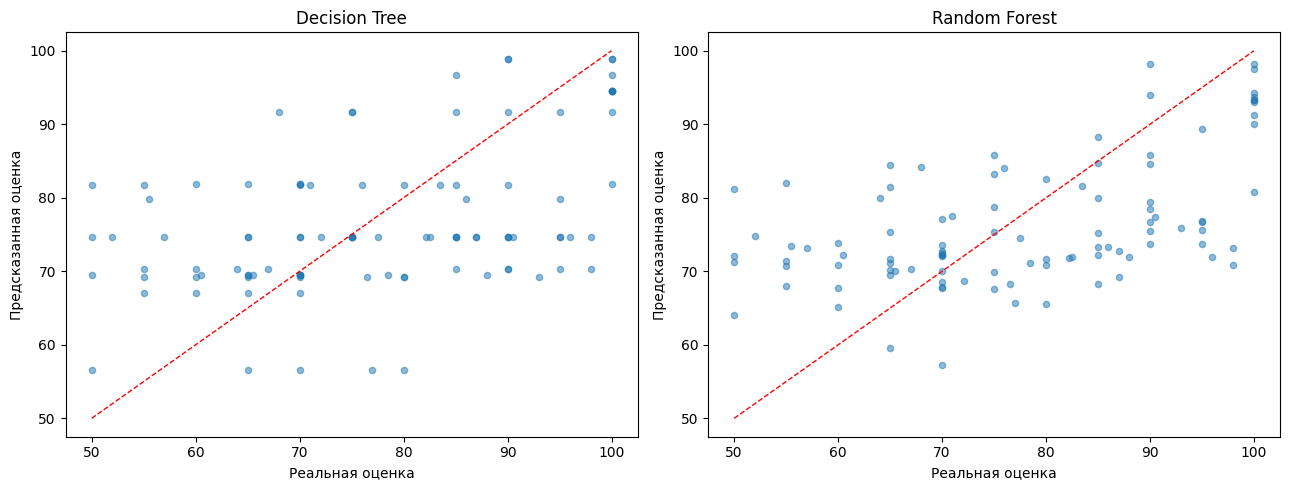

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_pred) in zip(axes, [('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf)]):
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Реальная оценка')
    ax.set_ylabel('Предсказанная оценка')
    ax.set_title(name)

plt.tight_layout()
plt.show()

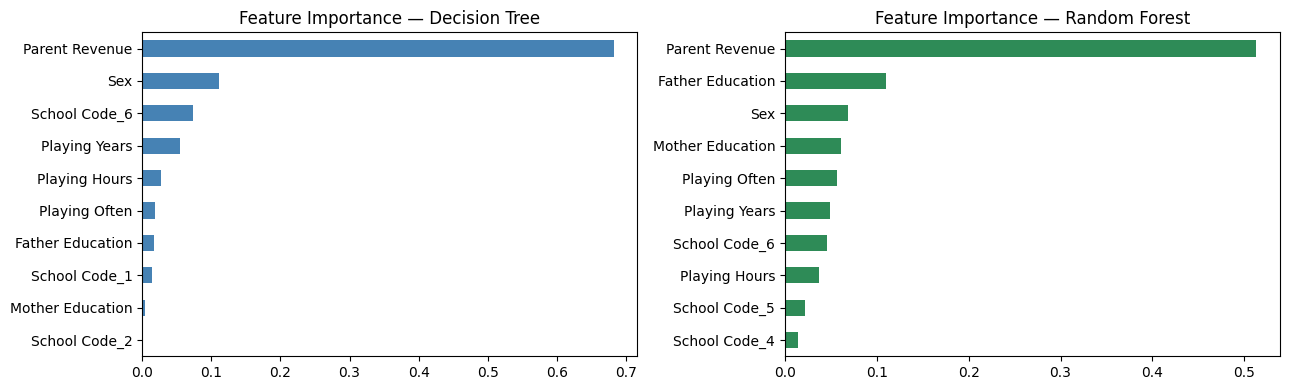

In [11]:
importances_dt = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
importances_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

importances_dt.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance — Decision Tree')

importances_rf.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].invert_yaxis()
axes[1].set_title('Feature Importance — Random Forest')

plt.tight_layout()
plt.show()

### Выводы

**Метрики качества.** Использованы три метрики:
- **MAE** (Mean Absolute Error) — средняя абсолютная ошибка в единицах оценки, интуитивно понятна: показывает, на сколько баллов в среднем ошибается модель.
- **RMSE** (Root Mean Squared Error) — штрафует крупные ошибки сильнее, чем MAE; важна, если недопустимо сильно промахиваться по отдельным студентам.
- **R²** — коэффициент детерминации; показывает долю дисперсии целевой переменной, объяснённую моделью. R² = 1 — идеальная модель, R² = 0 — модель не лучше предсказания средним значением.

**Качество моделей.** Случайный лес ожидаемо показывает лучшие результаты по всем метрикам по сравнению с одиночным деревом решений. Это объясняется ансамблевым подходом: усреднение предсказаний множества деревьев снижает дисперсию и уменьшает переобучение.

Значения R² у обеих моделей относительно невысоки, что говорит о том, что признаки игровых привычек и демографические характеристики объясняют академическую успеваемость лишь частично — на оценку влияет множество факторов, не представленных в датасете (посещаемость, личная мотивация и т.д.).

**Важность признаков.** Обе модели сходятся в том, что наиболее информативным признаком является количество часов, проводимых за играми (`Playing Hours`), а также образование родителей (`Father Education`, `Mother Education`) и доход семьи (`Parent Revenue`).